# Hospital Inpatient Charges Prediction
*summary of what this notebook is*

## Load Data
Import the CSV into a pandas DataFrame. Inspect its shape, dtypes, and column
names (note that column names may contain leading/trailing spaces that need stripping).


In [11]:
# Import modules
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from insurance_charges_prediction.load_data import load_raw_data
from insurance_charges_prediction.clean_data import clean_raw_data, drop_cols

In [12]:
# Load raw data
df = load_raw_data()

# Inspect Data
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 163065 entries, 0 to 163064
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype
---  ------                                --------------   -----
 0   DRG Definition                        163065 non-null  str  
 1   Provider Id                           163065 non-null  int64
 2   Provider Name                         163065 non-null  str  
 3   Provider Street Address               163065 non-null  str  
 4   Provider City                         163065 non-null  str  
 5   Provider State                        163065 non-null  str  
 6   Provider Zip Code                     163065 non-null  int64
 7   Hospital Referral Region Description  163065 non-null  str  
 8   Total Discharges                      163065 non-null  int64
 9   Average Covered Charges               163065 non-null  str  
 10  Average Total Payments                163065 non-null  str  
 11  Average Medicare Payments            

,DRG Definition,Provider Id,Provider Name,Provider Street Address,Provider City,Provider State,Provider Zip Code,Hospital Referral Region Description,Total Discharges,Average Covered Charges,Average Total Payments,Average Medicare Payments
0,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,AL - Dothan,91,$32963.07,$5777.24,$4763.73
1,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,AL - Birmingham,14,$15131.85,$5787.57,$4976.71
2,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10006,ELIZA COFFEE MEMORIAL HOSPITAL,205 MARENGO STREET,FLORENCE,AL,35631,AL - Birmingham,24,$37560.37,$5434.95,$4453.79
3,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10011,ST VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,AL - Birmingham,25,$13998.28,$5417.56,$4129.16
4,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10016,SHELBY BAPTIST MEDICAL CENTER,1000 FIRST STREET NORTH,ALABASTER,AL,35007,AL - Birmingham,18,$31633.27,$5658.33,$4851.44


## Clean Data
Average Covered Charges, Average Total Payments, and Average
Medicare Payments are stored as text (e.g. 32,963.07). Strip the dollar sign and comma separators
and convert them to numeric (float) columns.

In [13]:
df = clean_raw_data(df)
df.head()

,DRG Definition,Provider Id,Provider Name,Provider Street Address,Provider City,Provider State,Provider Zip Code,Hospital Referral Region Description,Total Discharges,Average Covered Charges,Average Total Payments,Average Medicare Payments
0,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10001,SOUTHEAST ALABAMA MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,AL - Dothan,91,32963.07,5777.24,4763.73
1,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,AL - Birmingham,14,15131.85,5787.57,4976.71
2,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10006,ELIZA COFFEE MEMORIAL HOSPITAL,205 MARENGO STREET,FLORENCE,AL,35631,AL - Birmingham,24,37560.37,5434.95,4453.79
3,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10011,ST VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,AL - Birmingham,25,13998.28,5417.56,4129.16
4,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,10016,SHELBY BAPTIST MEDICAL CENTER,1000 FIRST STREET NORTH,ALABASTER,AL,35007,AL - Birmingham,18,31633.27,5658.33,4851.44


## Drop Unecessary Columns
Drop columns that are identifiers rather than useful predictors for a general
pricing model: Provider Id, Provider Name, Provider Street Address, and Provider Zip Code.

In [14]:
df = drop_cols(df)
df.head()

,DRG Definition,Provider City,Provider State,Hospital Referral Region Description,Total Discharges,Average Covered Charges,Average Total Payments,Average Medicare Payments
0,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,DOTHAN,AL,AL - Dothan,91,32963.07,5777.24,4763.73
1,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,BOAZ,AL,AL - Birmingham,14,15131.85,5787.57,4976.71
2,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,FLORENCE,AL,AL - Birmingham,24,37560.37,5434.95,4453.79
3,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,BIRMINGHAM,AL,AL - Birmingham,25,13998.28,5417.56,4129.16
4,039 - EXTRACRANIAL PROCEDURES W/O CC/MCC,ALABASTER,AL,AL - Birmingham,18,31633.27,5658.33,4851.44


# Exploratory Data Analysis

This notebook covers only the exploratory data analysis portion of the *Insurance Charges Prediction*

**Dataset:** `inpatienCharges` - real, publicly released U.S. Centers for Medicare &
Medicaid Services (CMS) billing data. ~163,000 rows, one row per hospital per DRG
(diagnosis-related group, i.e. billed procedure/condition category). The target we care
about is **Average Covered Charges** — what the hospital billed, on average, for that DRG.

**What this EDA is trying to answer** before any model gets built:
1. What does the distribution of charges look like — is it safe to treat it as roughly
   normal, or is it skewed in a way that matters?
2. How much do charges vary by *procedure type* (DRG) versus by *hospital location*
   (state) — which one looks like the bigger cost driver?

In [15]:
PALETTE = {
    "blue": "#2a78d6",
    "surface": "#fcfcfb",
    "ink_primary": "#0b0b0b",
    "ink_secondary": "#52514e",
    "grid": "#e1e0d9",
    "axis": "#c3c2b7",
}

sns.set_style("whitegrid", {
    "axes.facecolor": PALETTE["surface"],
    "figure.facecolor": PALETTE["surface"],
    "grid.color": PALETTE["grid"],
    "axes.edgecolor": PALETTE["axis"],
    "text.color": PALETTE["ink_primary"],
    "axes.labelcolor": PALETTE["ink_primary"],
    "xtick.color": PALETTE["ink_secondary"],
    "ytick.color": PALETTE["ink_secondary"],
})

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DOLLARS = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")


## Missing Values and Duplicate Rows

Checking this now, before plotting, rather than after: a null would silently vanish from a
histogram or distort a group median, and a duplicated row would double-count a hospital's
charges in any aggregate view. Better to know now than to explain a strange-looking chart
later.

In [16]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Exact duplicate rows (current columns):", df.duplicated().sum())

Missing values per column:
DRG Definition                          0
Provider City                           0
Provider State                          0
Hospital Referral Region Description    0
Total Discharges                        0
Average Covered Charges                 0
Average Total Payments                  0
Average Medicare Payments               0
dtype: int64

Exact duplicate rows (current columns): 0


**Findings and reasoning:**

- **Missing values: none, in any column.** This isn't surprising for this particular file
  — it's a single already-aggregated CMS extract (one row per hospital-DRG pair) rather
  than raw transactional billing data, so it doesn't carry the partially-filled-in records
  you'd see from a live claims feed. Nothing to impute or drop.
- **Duplicate rows: none**, even after dropping the identifier columns. That second check
  matters: two *different* hospitals could plausibly report an identical DRG + state +
  discharge count + set of charges by coincidence, which would look like a duplicate on the
  reduced columns without actually being one — dropping it would silently delete a real
  hospital's data. Since the count is zero, that judgment call doesn't end up mattering here,
  but it's the reason the check was run on the trimmed columns rather than assumed safe.
- If either check *had* turned up something: exact duplicate rows would be dropped outright
  (they can only be a re-extract artifact, since `Provider Id` guarantees genuine per-hospital
  uniqueness), while missing numeric values would be a candidate for **median imputation
  grouped by `DRG Definition`** rather than a single global median — a routine appendectomy
  and a multi-day ICU stay have wildly different typical charges, and a global median would
  blur that away.

## Exploratory visualizations

Three questions, three charts: what does the target variable look like on its own, how
does it move across procedure type, and how does it move across geography.

### Distribution of `Average Covered Charges`

**Chart choice — histogram (with median/mean markers) rather than a summary statistic
table.** The job here is "show the shape of a single continuous variable" — is it roughly
symmetric, bimodal, heavy-tailed? A table of mean/std can't answer that; a histogram can,
at a glance. Since there's exactly one series, it gets one consistent hue and no legend
box is needed for identity — only reference lines for median and mean, which do need a
small legend since they're two distinct annotations layered on the same chart.

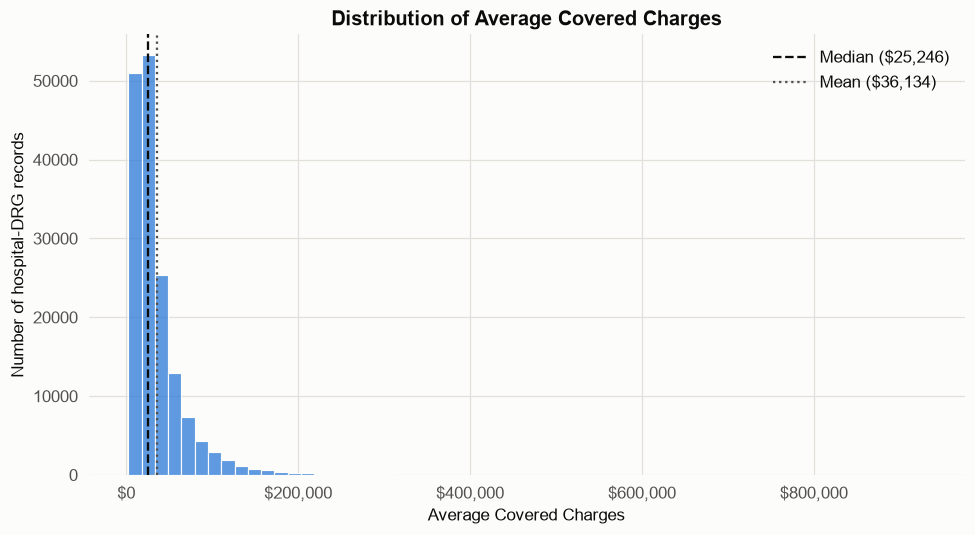

Skewness: 4.03
Min: $2,459.40   Max: $929,118.90


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(df["Average Covered Charges"], bins=60, color=PALETTE["blue"],
             edgecolor=PALETTE["surface"], ax=ax)

median_val = df["Average Covered Charges"].median()
mean_val = df["Average Covered Charges"].mean()
ax.axvline(median_val, color=PALETTE["ink_primary"], linestyle="--", linewidth=1.5,
           label=f"Median (${median_val:,.0f})")
ax.axvline(mean_val, color=PALETTE["ink_secondary"], linestyle=":", linewidth=1.5,
           label=f"Mean (${mean_val:,.0f})")

ax.set_title("Distribution of Average Covered Charges", fontsize=13, weight="bold")
ax.set_xlabel("Average Covered Charges")
ax.set_ylabel("Number of hospital-DRG records")
ax.xaxis.set_major_formatter(DOLLARS)
ax.legend(frameon=False)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

print(f"Skewness: {df['Average Covered Charges'].skew():.2f}")
print(f"Min: ${df['Average Covered Charges'].min():,.2f}   Max: ${df['Average Covered Charges'].max():,.2f}")

**Reading it:** the distribution is heavily **right-skewed** (skewness ≈ 4.0) — most
hospital-DRG charges cluster in the low tens of thousands of dollars, but a long tail of
much larger charges (into the hundreds of thousands) pulls the mean (~\$36.1K) well above
the median (~\$25.2K). That gap between mean and median is itself informative: it's the
signature of a variable driven by a relatively small number of very expensive procedures
rather than one that's uniformly spread out. It's the kind of shape that would typically
push someone modelling this variable toward evaluating a log-transform of the target —
noted here as an observation for that later step, not something this notebook acts on.

### Average Covered Charges across the 15 most frequent DRG categories

**Chart choice — box plot, not a bar chart of means.** `DRG Definition` has 100 distinct
categories; the brief calls for the 10-15 most frequent so labels stay readable while still
covering a meaningful slice of the data (the 15 shown below account for about a quarter of
all rows). A bar chart of *mean* charge per DRG would collapse each category to a single
number and hide exactly the thing that matters for cost data — spread and outliers. A box
plot keeps the median, interquartile range, and outliers visible, which is what "how do
charges vary" actually needs. Categories are sorted by median (highest first) so the ranking
reads directly off the y-axis instead of requiring a legend, and — again, one measure, one
consistent hue.

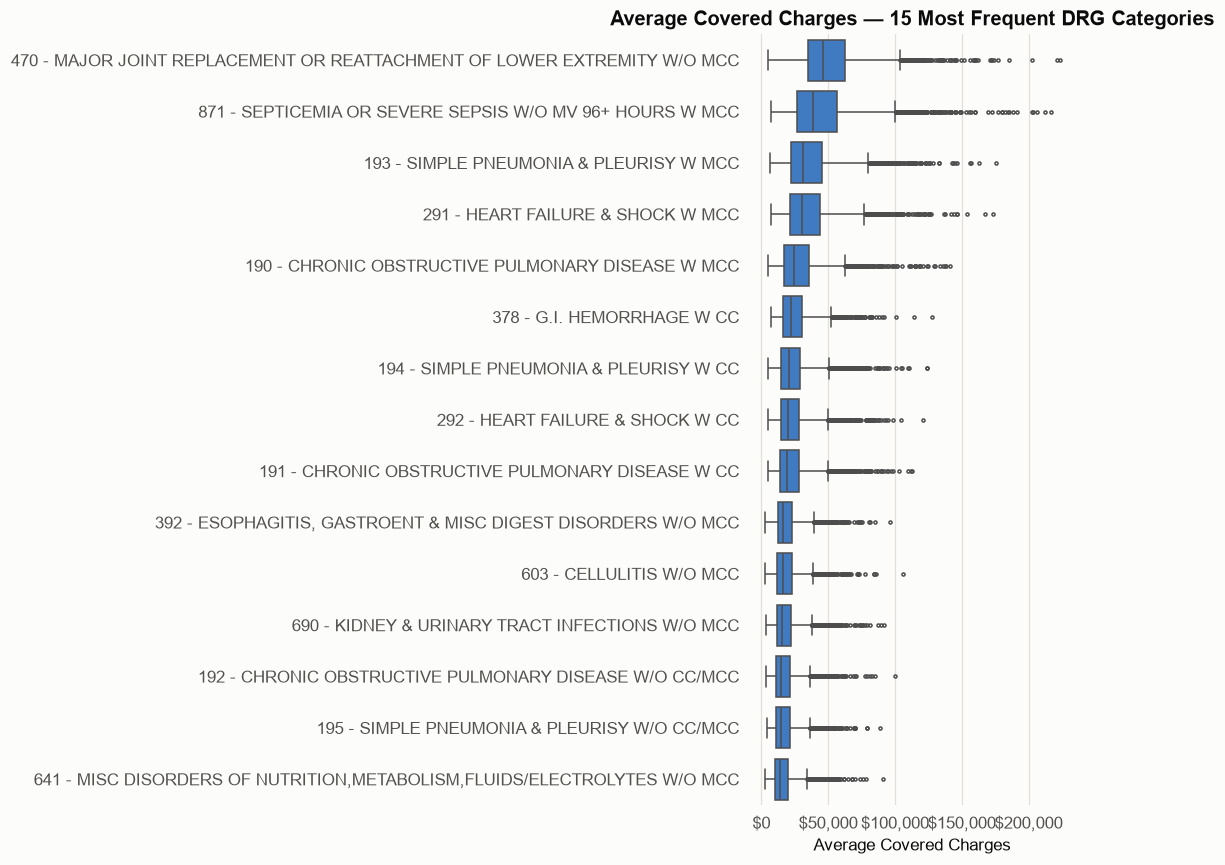

These 15 DRGs account for 25.6% of all rows.


In [18]:
top_drgs = df["DRG Definition"].value_counts().nlargest(15)
subset = df[df["DRG Definition"].isin(top_drgs.index)]
order = (
    subset.groupby("DRG Definition")["Average Covered Charges"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=subset, x="Average Covered Charges", y="DRG Definition", order=order,
            color=PALETTE["blue"], fliersize=2, linewidth=1, ax=ax)

ax.set_title("Average Covered Charges — 15 Most Frequent DRG Categories", weight="bold")
ax.set_xlabel("Average Covered Charges")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(DOLLARS)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

coverage = top_drgs.sum() / len(df)
print(f"These 15 DRGs account for {coverage:.1%} of all rows.")

**Reading it:** even restricted to just the most *common* DRGs (as opposed to the most
*expensive* ones, which aren't shown here), typical charges range roughly from the low
teens of thousands (e.g. cardiac arrhythmia without complications) up past \$30K (e.g.
major joint replacement, sepsis-related stays) — a real spread driven by clinical
complexity, before geography enters the picture at all. Boxes for the pulmonary/heart-failure
DRGs are also visibly wider with more high-side outliers than e.g. the digestive-disorder
DRGs, meaning "typical procedure cost" varies not just in its center but in how consistent
it is.

### Average Covered Charges by state

**Chart choice — same box plot form, but all 51 states/DC shown**, not a top-N subset.
Unlike `DRG Definition`, `Provider State` only has 51 possible values, so there's no
readability trade-off in truncating it — showing all of them gives the complete geographic
picture rather than an arbitrary "most common" cut (every state has plenty of hospitals in
this dataset, so "most frequent" wouldn't mean much here anyway). Sorted by median again,
same single hue, taller figure to fit 51 rows legibly.

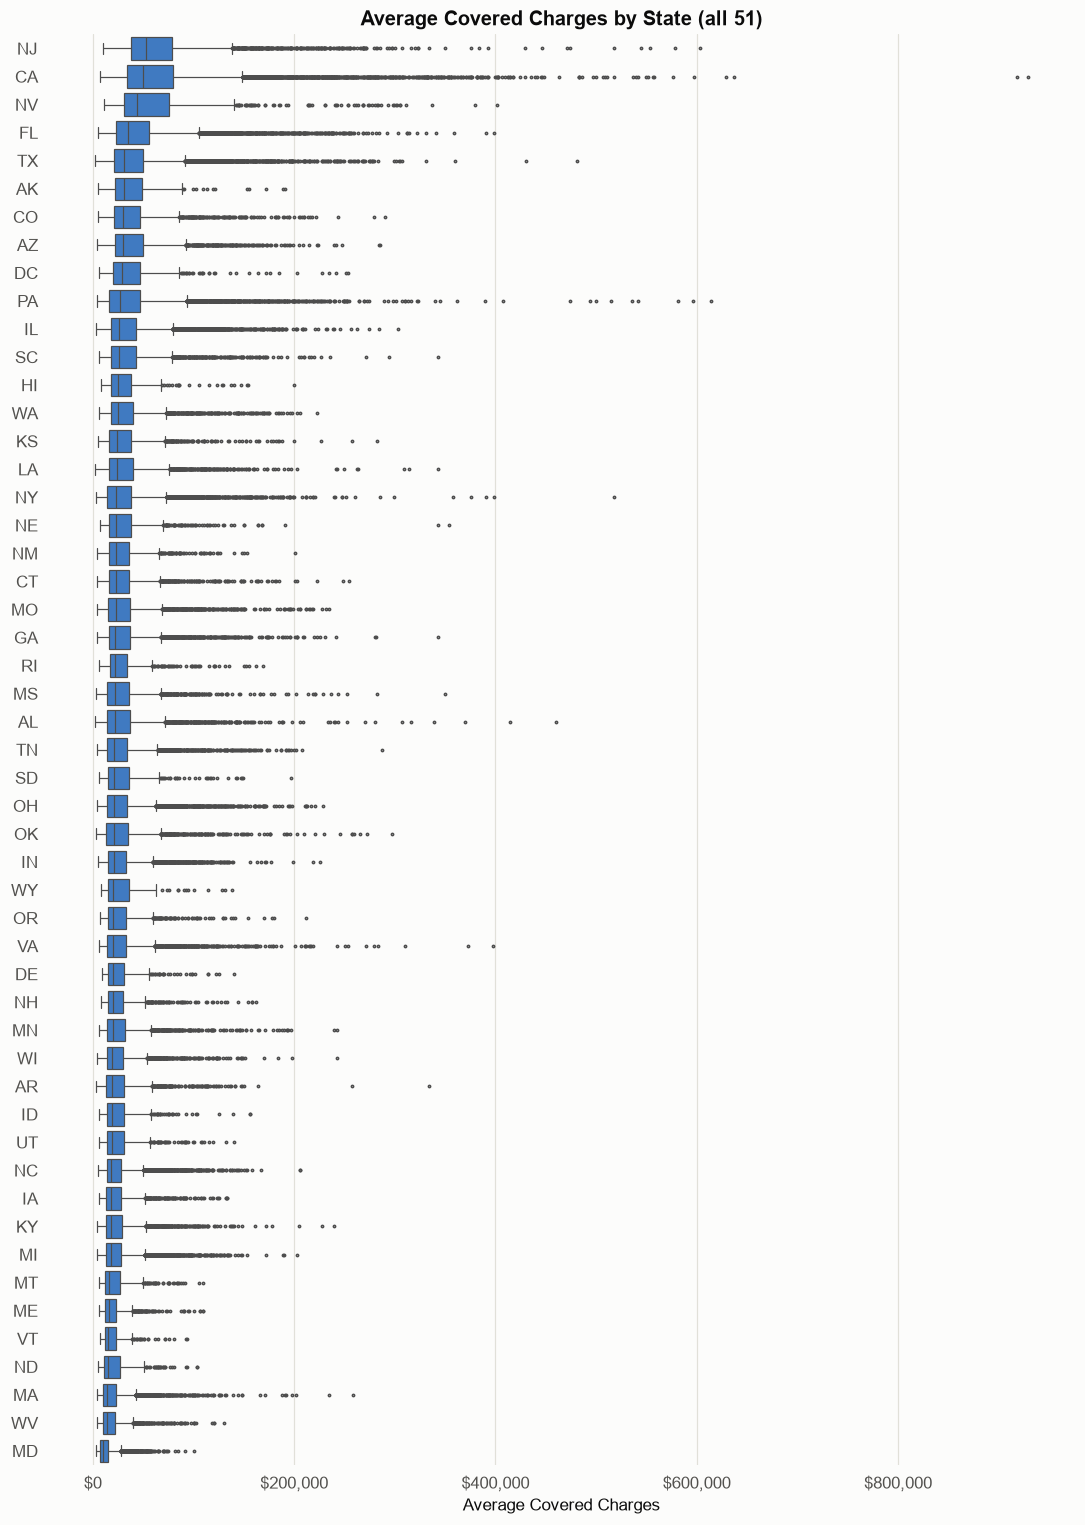

In [19]:
order_state = (
    df.groupby("Provider State")["Average Covered Charges"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(10, 14))
sns.boxplot(data=df, x="Average Covered Charges", y="Provider State", order=order_state,
            color=PALETTE["blue"], fliersize=1.5, linewidth=0.8, ax=ax)

ax.set_title("Average Covered Charges by State (all 51)", weight="bold")
ax.set_xlabel("Average Covered Charges")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(DOLLARS)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Reading it:** there's a real geographic gradient — New Jersey and California sit at the
top with typical charges above \$45K, while Maryland and West Virginia sit under \$14K —
but the *overall* spread across states is visually narrower than the spread across DRGs in
5.2, and the boxes overlap each other far more than the DRG boxes did. State looks like it
shifts charges up or down, more than it explains dramatically different charge levels the
way procedure type does.

### Quantifying which factor explains more variation

Eyeballing box-plot spread is suggestive but not a real answer, and the two charts above
aren't even on equal footing — 5.2 only showed 15 of the 100 DRGs. To actually answer "which
variable explains more of the variation," this computes **eta-squared (η²)** for each
grouping variable: the share of the *total* variance in `Average Covered Charges` that's
explained by which group a row belongs to (i.e. `SS_between / SS_total`), using *all*
categories of each variable, not just the ones that fit on a chart.

In [20]:
def eta_squared(frame, group_col, value_col):
    grand_mean = frame[value_col].mean()
    ss_total = ((frame[value_col] - grand_mean) ** 2).sum()
    group_stats = frame.groupby(group_col)[value_col].agg(["mean", "count"])
    ss_between = (group_stats["count"] * (group_stats["mean"] - grand_mean) ** 2).sum()
    return ss_between / ss_total

eta_drg = eta_squared(df, "DRG Definition", "Average Covered Charges")
eta_state = eta_squared(df, "Provider State", "Average Covered Charges")

print("Share of variance in Average Covered Charges explained by group membership:")
print(f"  DRG Definition ({df['DRG Definition'].nunique()} categories):  eta^2 = {eta_drg:.3f}")
print(f"  Provider State ({df['Provider State'].nunique()} categories):   eta^2 = {eta_state:.3f}")

Share of variance in Average Covered Charges explained by group membership:
  DRG Definition (100 categories):  eta^2 = 0.536
  Provider State (51 categories):   eta^2 = 0.141


**Reading it:** `DRG Definition` explains about **54% of the total variance** in charges,
versus about **14% for `Provider State`** — confirming what the box plots suggested visually,
now on a like-for-like basis across every category of each variable. Procedure type is by
far the dominant driver of how much a hospital bills; state/geography shifts the number
meaningfully but is a secondary effect. That's consistent with domain intuition: the
clinical resources a DRG requires (ICU days, ventilator time, surgical complexity) set the
baseline cost, while regional pricing power adjusts it up or down from there — it doesn't
create cost differences of the same magnitude on its own.

Together, the two numbers also leave roughly 32% of the variance unexplained by either
variable alone — a reminder that a model using both (plus discharge volume) still won't
fit charges perfectly, and that's expected rather than a problem to chase away.

## Summary

This notebook covered the EDA slice of the brief: the raw CSV loads with whitespace-padded
column names and currency-as-text charge columns, both fixed before any analysis; four
per-hospital identifier columns were dropped as non-generalizable; there are no missing
values or duplicate rows to handle, even after that column reduction. `Average Covered
Charges` is heavily right-skewed (skew ≈ 4.0, mean well above median), and procedure type
(`DRG Definition`) explains roughly 4x more of its variance (η² ≈ 0.54) than hospital state
does (η² ≈ 0.14) — the clearest signal in this data is *what* was done, not *where*.

Encoding the categoricals, the train/test split, model fitting/evaluation, coefficient
interpretation, and the regularized-regression comparison are the next steps of the full
brief and belong in a separate modelling notebook (e.g. `hospital_charges_prediction.ipynb`)
— out of scope here by request.

## Handoff to the Modelling Notebook

Writing the cleaned, trimmed DataFrame out to `data/processed/` here so the modelling
notebook (`hospital_charges_prediction.ipynb`) can read it directly instead of re-running
the load/clean/drop steps above.

In [ ]:
from insurance_charges_prediction.config import CLEANED_DATA_FILE

CLEANED_DATA_FILE.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(CLEANED_DATA_FILE, index=False)
print(f"Wrote cleaned data to {CLEANED_DATA_FILE}")